Import & load data

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('D:\DEPI 2025-2026\MLOps\ML\Decision Tree\Admission_Predict.csv')
df.head()

<>:8: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:8: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\ITECH STORE\AppData\Local\Temp\ipykernel_3916\468066256.py:8: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  df = pd.read_csv('D:\DEPI 2025-2026\MLOps\ML\Decision Tree\Admission_Predict.csv')


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


Exploratory Data Analysis (EDA)

In [50]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [51]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

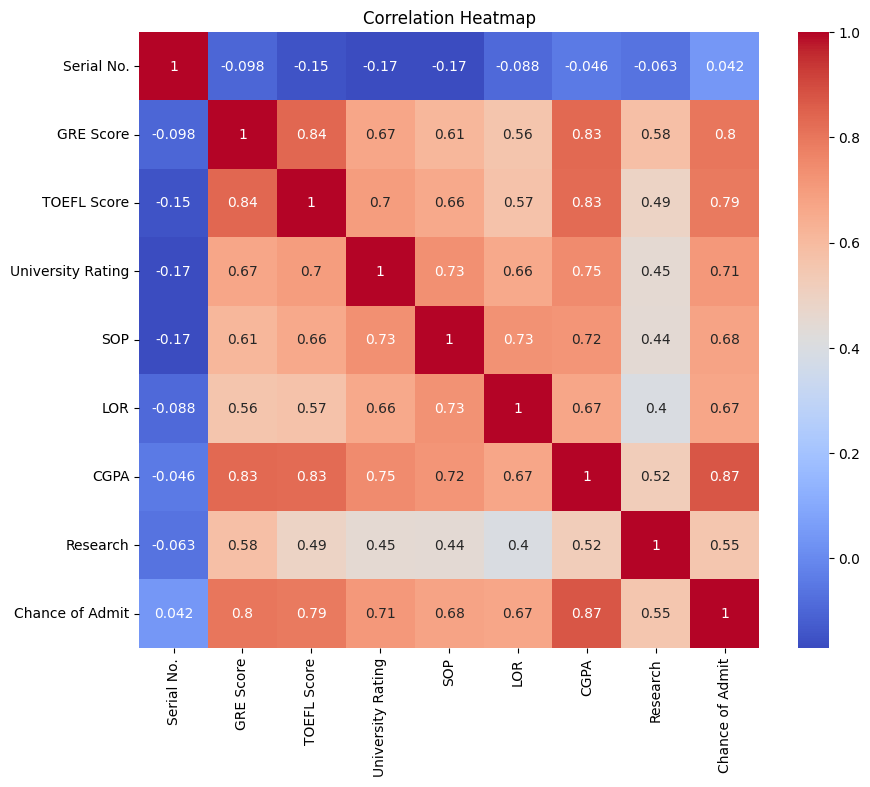

In [52]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Preprocessing

In [53]:
df = df.drop('Serial No.', axis=1)
df.shape

(400, 8)

In [54]:
df['Chance of Admit'] = df['Chance of Admit']>=0.75
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,True
1,324,107,4,4.0,4.5,8.87,1,True
2,316,104,3,3.0,3.5,8.00,1,False
3,322,110,3,3.5,2.5,8.67,1,True
4,314,103,2,2.0,3.0,8.21,0,False
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,True
396,325,107,3,3.0,3.5,9.11,1,True
397,330,116,4,5.0,4.5,9.45,1,True
398,312,103,3,3.5,4.0,8.78,0,False


In [55]:
X = df.drop('Chance of Admit', axis=1)
y = df['Chance of Admit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
model.fit(X_train, y_train)

print(f"Training Accuracy: {model.score(X_train, y_train)}")
print(f"Testing Accuracy: {model.score(X_test, y_test)}")

Training Accuracy: 0.890625
Testing Accuracy: 0.9375


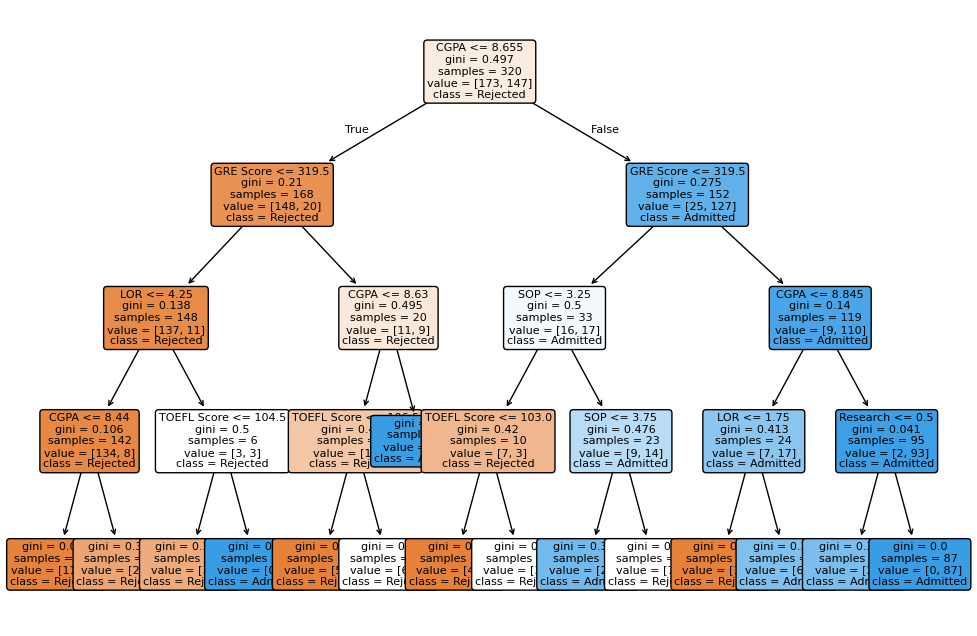

In [56]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model, 
          filled=True, 
          feature_names=X.columns, 
          class_names=['Rejected', 'Admitted'], 
          rounded=True,
          fontsize=8) 
plt.show()